Leads Reales

In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde el archivo .csv ya limpio (ajusta la ruta si no esta en la misma carpeta que este notebook)
Leads_Reales = pd.read_csv('Leads_Reales_Limpia.csv', encoding='utf-8-sig')

In [3]:
# Ajustar maximo de filas
pd.options.display.max_rows = None

In [4]:
#Corroboramos valores nulos
valores_nulos = Leads_Reales.isnull().sum()
valores_nulos

Año                         0
Mes                         0
Total                       1
Ilocalizable                1
No Contesta                 1
D. Incorrectos              1
Duplicados                  1
Efectivos                   1
Abiertos                    1
Ventas                      1
Conversion (%)              1
Efectividad de Leads (%)    1
dtype: int64

Variable No Contesta

In [5]:
#Calculamos el numero total de la población "n"
Leads_Reales['No Contesta'].info()
n = Leads_Reales['No Contesta'].notna().sum()
n

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: No Contesta
Non-Null Count  Dtype  
--------------  -----  
28 non-null     float64
dtypes: float64(1)
memory usage: 364.0 bytes


np.int64(28)

In [6]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max = Leads_Reales['No Contesta'].max()
Min = Leads_Reales['No Contesta'].min()
Limites = [Min, Max]
Limites

[np.float64(13.0), np.float64(606.0)]

In [7]:
#Calculamos el rango R
R = Max - Min
R

np.float64(593.0)

In [8]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni = 1 + 3.32*np.log10(n)
ni

np.float64(5.8045646640561674)

In [9]:
#Calculamos el Ancho del Intervalo "i"
i = R/ni
i

np.float64(102.16097749277513)

**Creación de Categorías a partir de clases**

In [10]:
#Categorización de variables
#Redondeamos ni al entero mas cercano para obtener el numero de intervalos
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad (el minimo -1, el maximo +1)
#con la intención de incluir los valores que caigan justo en los límites
ni_redondeado = round(ni)
intervalos = np.linspace(Min-1, Max+1, ni_redondeado+1)
intervalos

array([ 12.        , 111.16666667, 210.33333333, 309.5       ,
       408.66666667, 507.83333333, 607.        ])

In [11]:
#Nombramos las categorías según su nivel de volumen de leads (de mas bajo a mas alto),
#en vez de un numero generico, para que el nombre tenga sentido con lo que se esta midiendo.
#Con 6 clases (las que nos dio Sturges) va un nivel por clase, de "Muy bajo" a "Muy alto"
niveles = ["Muy bajo", "Bajo", "Medio bajo", "Medio alto", "Alto", "Muy alto"]
categorias = [f"{niveles[k]} ({intervalos[k]:.1f}-{intervalos[k+1]:.1f})" for k in range(len(intervalos)-1)]
categorias

['Muy bajo (12.0-111.2)',
 'Bajo (111.2-210.3)',
 'Medio bajo (210.3-309.5)',
 'Medio alto (309.5-408.7)',
 'Alto (408.7-507.8)',
 'Muy alto (507.8-607.0)']

In [12]:
#Finalmente creamos las categorías en la columna numérica
Leads_Reales['No Contesta'] = pd.cut(x=Leads_Reales['No Contesta'], bins=intervalos, labels=categorias)
Leads_Reales['No Contesta']

0                          NaN
1        Muy bajo (12.0-111.2)
2        Muy bajo (12.0-111.2)
3        Muy bajo (12.0-111.2)
4        Muy bajo (12.0-111.2)
5           Bajo (111.2-210.3)
6     Medio bajo (210.3-309.5)
7     Medio alto (309.5-408.7)
8     Medio alto (309.5-408.7)
9       Muy alto (507.8-607.0)
10    Medio alto (309.5-408.7)
11          Bajo (111.2-210.3)
12       Muy bajo (12.0-111.2)
13       Muy bajo (12.0-111.2)
14       Muy bajo (12.0-111.2)
15          Bajo (111.2-210.3)
16       Muy bajo (12.0-111.2)
17    Medio bajo (210.3-309.5)
18    Medio bajo (210.3-309.5)
19      Muy alto (507.8-607.0)
20    Medio alto (309.5-408.7)
21          Alto (408.7-507.8)
22    Medio bajo (210.3-309.5)
23          Bajo (111.2-210.3)
24          Bajo (111.2-210.3)
25       Muy bajo (12.0-111.2)
26          Bajo (111.2-210.3)
27          Bajo (111.2-210.3)
28          Bajo (111.2-210.3)
Name: No Contesta, dtype: category
Categories (6, str): ['Muy bajo (12.0-111.2)' < 'Bajo (111.2-210.3

In [13]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Leads_Reales['No Contesta'].value_counts().reset_index()
Tabla_freq

,No Contesta,count
0,Muy bajo (12.0-111.2),9
1,Bajo (111.2-210.3),8
2,Medio bajo (210.3-309.5),4
3,Medio alto (309.5-408.7),4
4,Muy alto (507.8-607.0),2
5,Alto (408.7-507.8),1


In [14]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,No Contesta,count
0,Muy bajo (12.0-111.2),9
1,Bajo (111.2-210.3),8
2,Medio bajo (210.3-309.5),4
3,Medio alto (309.5-408.7),4
4,Muy alto (507.8-607.0),2
5,Alto (408.7-507.8),1


In [15]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('No Contesta')
Filtro_index

,count
No Contesta,
Muy bajo (12.0-111.2),9
Bajo (111.2-210.3),8
Medio bajo (210.3-309.5),4
Medio alto (309.5-408.7),4
Muy alto (507.8-607.0),2
Alto (408.7-507.8),1


Text(0, 0.5, 'Frecuencia')

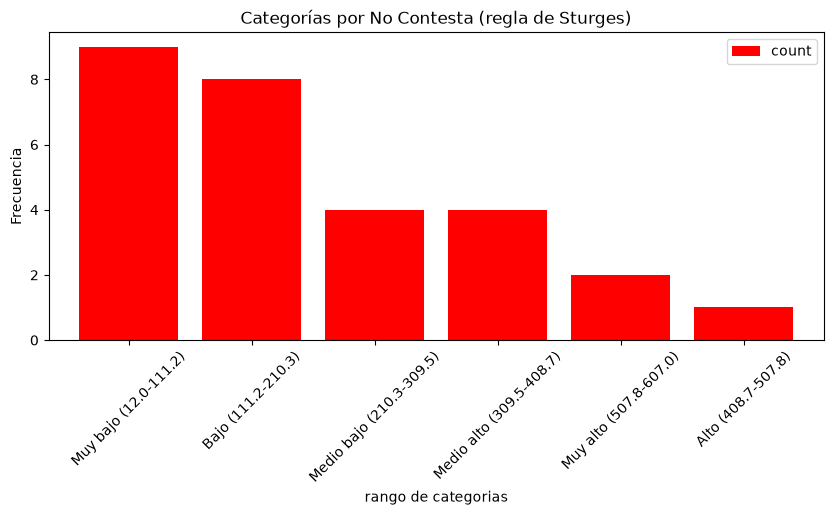

In [16]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red", rot=45)
plt.title('Categorías por No Contesta (regla de Sturges)')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

Variable Ilocalizable

In [17]:
#Calculamos el numero total de la población "n"
Leads_Reales['Ilocalizable'].info()
n = Leads_Reales['Ilocalizable'].notna().sum()
n

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Ilocalizable
Non-Null Count  Dtype  
--------------  -----  
28 non-null     float64
dtypes: float64(1)
memory usage: 364.0 bytes


np.int64(28)

In [18]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max = Leads_Reales['Ilocalizable'].max()
Min = Leads_Reales['Ilocalizable'].min()
Limites = [Min, Max]
Limites

[np.float64(5.0), np.float64(514.0)]

In [19]:
#Calculamos el rango R
R = Max - Min
R

np.float64(509.0)

In [20]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni = 1 + 3.32*np.log10(n)
ni

np.float64(5.8045646640561674)

In [21]:
#Calculamos el Ancho del Intervalo "i"
i = R/ni
i

np.float64(87.68960799970075)

**Creación de Categorías a partir de clases**

In [22]:
#Categorización de variables
#Redondeamos ni al entero mas cercano para obtener el numero de intervalos
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad (el minimo -1, el maximo +1)
#con la intención de incluir los valores que caigan justo en los límites
ni_redondeado = round(ni)
intervalos = np.linspace(Min-1, Max+1, ni_redondeado+1)
intervalos

array([  4.        ,  89.16666667, 174.33333333, 259.5       ,
       344.66666667, 429.83333333, 515.        ])

In [23]:
#Nombramos las categorías según su nivel de volumen de leads (de mas bajo a mas alto),
#en vez de un numero generico, para que el nombre tenga sentido con lo que se esta midiendo.
#Con 6 clases (las que nos dio Sturges) va un nivel por clase, de "Muy bajo" a "Muy alto"
niveles = ["Muy bajo", "Bajo", "Medio bajo", "Medio alto", "Alto", "Muy alto"]
categorias = [f"{niveles[k]} ({intervalos[k]:.1f}-{intervalos[k+1]:.1f})" for k in range(len(intervalos)-1)]
categorias

['Muy bajo (4.0-89.2)',
 'Bajo (89.2-174.3)',
 'Medio bajo (174.3-259.5)',
 'Medio alto (259.5-344.7)',
 'Alto (344.7-429.8)',
 'Muy alto (429.8-515.0)']

In [24]:
#Finalmente creamos las categorías en la columna numérica
Leads_Reales['Ilocalizable'] = pd.cut(x=Leads_Reales['Ilocalizable'], bins=intervalos, labels=categorias)
Leads_Reales['Ilocalizable']

0                          NaN
1            Bajo (89.2-174.3)
2          Muy bajo (4.0-89.2)
3          Muy bajo (4.0-89.2)
4          Muy bajo (4.0-89.2)
5            Bajo (89.2-174.3)
6            Bajo (89.2-174.3)
7       Muy alto (429.8-515.0)
8       Muy alto (429.8-515.0)
9       Muy alto (429.8-515.0)
10           Bajo (89.2-174.3)
11          Alto (344.7-429.8)
12         Muy bajo (4.0-89.2)
13         Muy bajo (4.0-89.2)
14         Muy bajo (4.0-89.2)
15         Muy bajo (4.0-89.2)
16         Muy bajo (4.0-89.2)
17         Muy bajo (4.0-89.2)
18           Bajo (89.2-174.3)
19         Muy bajo (4.0-89.2)
20         Muy bajo (4.0-89.2)
21         Muy bajo (4.0-89.2)
22         Muy bajo (4.0-89.2)
23           Bajo (89.2-174.3)
24           Bajo (89.2-174.3)
25           Bajo (89.2-174.3)
26    Medio bajo (174.3-259.5)
27    Medio bajo (174.3-259.5)
28           Bajo (89.2-174.3)
Name: Ilocalizable, dtype: category
Categories (6, str): ['Muy bajo (4.0-89.2)' < 'Bajo (89.2-174.3)'

In [25]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Leads_Reales['Ilocalizable'].value_counts().reset_index()
Tabla_freq

,Ilocalizable,count
0,Muy bajo (4.0-89.2),13
1,Bajo (89.2-174.3),9
2,Muy alto (429.8-515.0),3
3,Medio bajo (174.3-259.5),2
4,Alto (344.7-429.8),1
5,Medio alto (259.5-344.7),0


In [26]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,Ilocalizable,count
0,Muy bajo (4.0-89.2),13
1,Bajo (89.2-174.3),9
2,Muy alto (429.8-515.0),3
3,Medio bajo (174.3-259.5),2
4,Alto (344.7-429.8),1


In [27]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Ilocalizable')
Filtro_index

,count
Ilocalizable,
Muy bajo (4.0-89.2),13
Bajo (89.2-174.3),9
Muy alto (429.8-515.0),3
Medio bajo (174.3-259.5),2
Alto (344.7-429.8),1


Text(0, 0.5, 'Frecuencia')

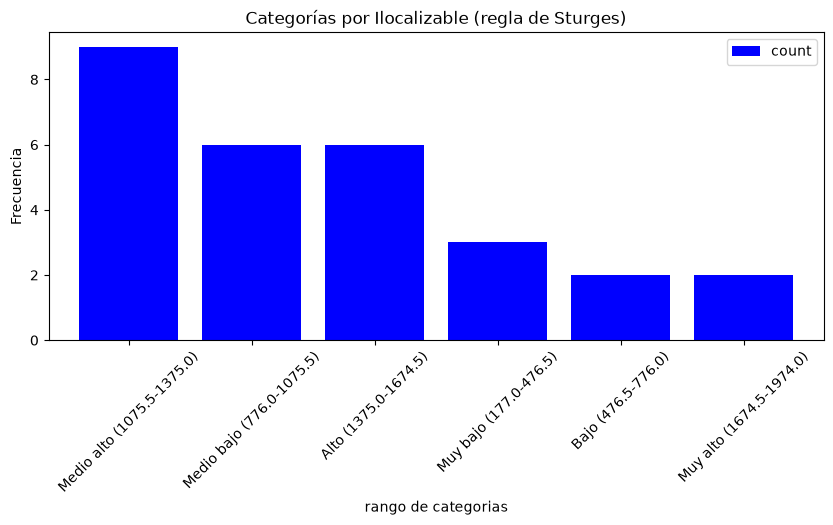

In [43]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Categorías por Ilocalizable (regla de Sturges)')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')

Variable Total

In [29]:
#Calculamos el numero total de la población "n"
Leads_Reales['Total'].info()
n = Leads_Reales['Total'].notna().sum()
n

<class 'pandas.Series'>
RangeIndex: 29 entries, 0 to 28
Series name: Total
Non-Null Count  Dtype  
--------------  -----  
28 non-null     float64
dtypes: float64(1)
memory usage: 364.0 bytes


np.int64(28)

In [30]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max = Leads_Reales['Total'].max()
Min = Leads_Reales['Total'].min()
Limites = [Min, Max]
Limites

[np.float64(178.0), np.float64(1973.0)]

In [31]:
#Calculamos el rango R
R = Max - Min
R

np.float64(1795.0)

In [32]:
#Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni = 1 + 3.32*np.log10(n)
ni

np.float64(5.8045646640561674)

In [33]:
#Calculamos el Ancho del Intervalo "i"
i = R/ni
i

np.float64(309.2393838103396)

**Creación de Categorías a partir de clases**

In [34]:
#Categorización de variables
#Redondeamos ni al entero mas cercano para obtener el numero de intervalos
#Ajustamos los limites para que todos los valores sean incluidos en los intervalos
#Ampliamos los límites en una unidad (el minimo -1, el maximo +1)
#con la intención de incluir los valores que caigan justo en los límites
ni_redondeado = round(ni)
intervalos = np.linspace(Min-1, Max+1, ni_redondeado+1)
intervalos

array([ 177. ,  476.5,  776. , 1075.5, 1375. , 1674.5, 1974. ])

In [35]:
#Nombramos las categorías según su nivel de volumen de leads (de mas bajo a mas alto),
#en vez de un numero generico, para que el nombre tenga sentido con lo que se esta midiendo.
#Con 6 clases (las que nos dio Sturges) va un nivel por clase, de "Muy bajo" a "Muy alto"
niveles = ["Muy bajo", "Bajo", "Medio bajo", "Medio alto", "Alto", "Muy alto"]
categorias = [f"{niveles[k]} ({intervalos[k]:.1f}-{intervalos[k+1]:.1f})" for k in range(len(intervalos)-1)]
categorias

['Muy bajo (177.0-476.5)',
 'Bajo (476.5-776.0)',
 'Medio bajo (776.0-1075.5)',
 'Medio alto (1075.5-1375.0)',
 'Alto (1375.0-1674.5)',
 'Muy alto (1674.5-1974.0)']

In [36]:
#Finalmente creamos las categorías en la columna numérica
Leads_Reales['Total'] = pd.cut(x=Leads_Reales['Total'], bins=intervalos, labels=categorias)
Leads_Reales['Total']

0                            NaN
1             Bajo (476.5-776.0)
2         Muy bajo (177.0-476.5)
3         Muy bajo (177.0-476.5)
4         Muy bajo (177.0-476.5)
5      Medio bajo (776.0-1075.5)
6      Medio bajo (776.0-1075.5)
7           Alto (1375.0-1674.5)
8     Medio alto (1075.5-1375.0)
9       Muy alto (1674.5-1974.0)
10          Alto (1375.0-1674.5)
11    Medio alto (1075.5-1375.0)
12     Medio bajo (776.0-1075.5)
13            Bajo (476.5-776.0)
14     Medio bajo (776.0-1075.5)
15    Medio alto (1075.5-1375.0)
16     Medio bajo (776.0-1075.5)
17    Medio alto (1075.5-1375.0)
18    Medio alto (1075.5-1375.0)
19          Alto (1375.0-1674.5)
20    Medio alto (1075.5-1375.0)
21    Medio alto (1075.5-1375.0)
22     Medio bajo (776.0-1075.5)
23          Alto (1375.0-1674.5)
24          Alto (1375.0-1674.5)
25    Medio alto (1075.5-1375.0)
26      Muy alto (1674.5-1974.0)
27          Alto (1375.0-1674.5)
28    Medio alto (1075.5-1375.0)
Name: Total, dtype: category
Categories (6,

In [37]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Leads_Reales['Total'].value_counts().reset_index()
Tabla_freq

,Total,count
0,Medio alto (1075.5-1375.0),9
1,Medio bajo (776.0-1075.5),6
2,Alto (1375.0-1674.5),6
3,Muy bajo (177.0-476.5),3
4,Bajo (476.5-776.0),2
5,Muy alto (1674.5-1974.0),2


In [38]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,Total,count
0,Medio alto (1075.5-1375.0),9
1,Medio bajo (776.0-1075.5),6
2,Alto (1375.0-1674.5),6
3,Muy bajo (177.0-476.5),3
4,Bajo (476.5-776.0),2
5,Muy alto (1674.5-1974.0),2


In [39]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Total')
Filtro_index

,count
Total,
Medio alto (1075.5-1375.0),9
Medio bajo (776.0-1075.5),6
Alto (1375.0-1674.5),6
Muy bajo (177.0-476.5),3
Bajo (476.5-776.0),2
Muy alto (1674.5-1974.0),2


Text(0, 0.5, 'Frecuencia')

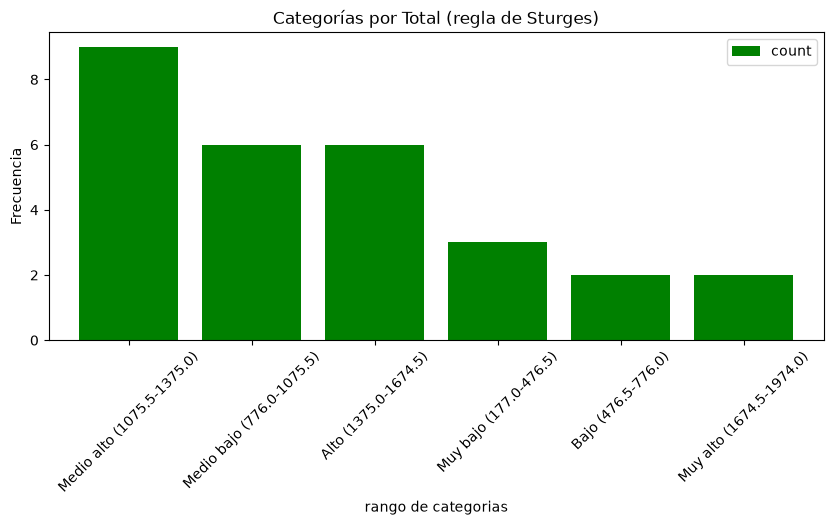

In [42]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "green", rot=45)
plt.title('Categorías por Total (regla de Sturges)')
plt.xlabel('rango de categorias')
plt.ylabel('Frecuencia')